# Shield Insurance — Premium Prediction for New Market
**Author:** Matthew  ·  **Date:** 29 Aug 2026  ·  **Dataset:** premiums_with_life_style.xlsx

## Objective
Build a regression model that predicts `Annual_Premium_Amount` from competitor data,
incorporating a business-defined lifestyle risk score, and identify the best model
and its hyperparameters.

## Contents
1. Load & Inspect
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering (incl. life_style_risk_score)
5. Train/Test Split & Scaling
6. Model Training & Feature Importance
7. Hyperparameter Tuning
8. Error Analysis (high-margin errors > 10%)
9. Conclusion

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Load and Inspect

In [2]:
df = pd.read_excel('premiums_with_life_style.xlsx')
print(df.shape)
df.head(2)

(10000, 15)


,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108


In [3]:
# Make all column headers lower case
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'physical_activity',
       'stress_level', 'number_of_dependants', 'bmi_category',
       'smoking_status', 'employment_status', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount'],
      dtype='str')

In [4]:
# Inspect all numerical columns
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.316300,3.192900,23.339900,19505.063900
std,57.971661,21.650454,32.302974,8893.649171
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11777.750000
50%,37.000000,2.000000,16.000000,19312.000000
75%,50.000000,3.000000,31.000000,26494.500000
max,1178.000000,456.000000,960.000000,45854.000000


## Data Cleaning

#### Handling misssing values


In [5]:
df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
physical_activity         0
stress_level              0
number_of_dependants      0
bmi_category              0
smoking_status            9
employment_status         7
income_level             18
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [6]:
# Since there are only a total of about 34 rows with null values, we can go ahead to drop them as they won't significantly affect the prediction

df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
physical_activity        0
stress_level             0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

#### Handling Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9973.000000,9973.000000,9973.000000,9973.000000
mean,41.319362,3.195628,23.382232,19503.816705
std,58.044687,21.679565,32.334811,8898.079736
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11774.000000
50%,37.000000,2.000000,16.000000,19314.000000
75%,50.000000,3.000000,31.000000,26500.000000
max,1178.000000,456.000000,960.000000,45854.000000


## Exploratory Data Analysis

### 1. Numeric Columns



#### Univarate Analysis: Numeric Columns

##### Box Plots for numeric columns

In [10]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='str')

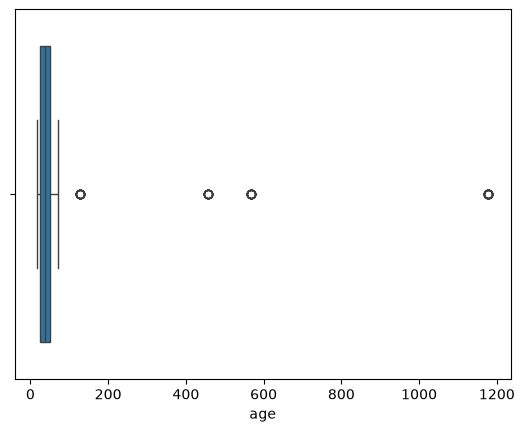

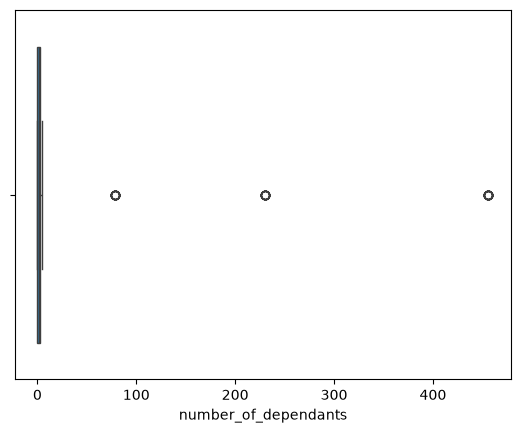

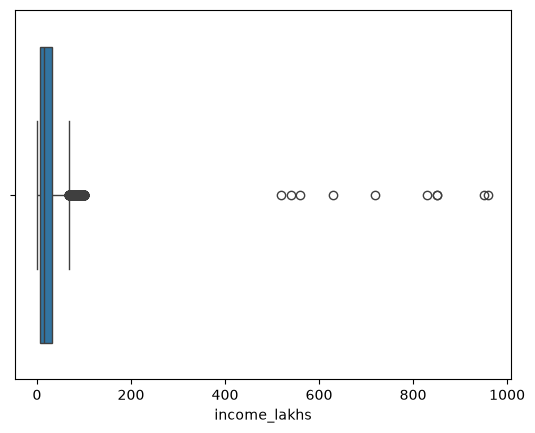

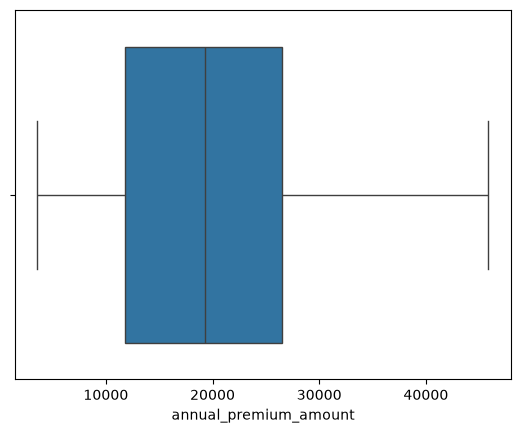

In [11]:
for col in numeric_columns:
   sns.boxplot(x= df[col])
   plt.show()

#### Outlier Treatment: Age Column

In [12]:
df[df['age']>100]['age'].unique()

array([ 128, 1178,  567,  456])

In [13]:
df1 = df[df['age']<=100]
df1['age'].describe()

count    9915.000000
mean       37.743621
std        13.975462
min        18.000000
25%        24.000000
50%        37.000000
75%        50.000000
max        72.000000
Name: age, dtype: float64

#### Outlier Treatment: Income Column

In [14]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

lower, upper = get_iqr_bounds(df1['income_lakhs'])
lower, upper

(-31.5, 68.5)

In [15]:
# How many data points are outliers based on the upper bounds

df1[df1.income_lakhs>upper].shape

(697, 15)

There are many legitimate records that we will get rid of if we use IQR bounds method. It will be better to use a simple quantile bound

In [16]:
quantile_threshold = df1.income_lakhs.quantile(0.999)
quantile_threshold

np.float64(136.11999999971886)

In [17]:
df1[df1['income_lakhs']>quantile_threshold].shape

(10, 15)

In [18]:
df2 = df1[df1['income_lakhs']<=quantile_threshold ].copy()
df2.shape

(9905, 15)

##### Outlier Treatment: Number of Dependents

In [19]:
df2.number_of_dependants.describe()

count    9905.000000
mean        3.205553
std        21.753158
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max       456.000000
Name: number_of_dependants, dtype: float64

There is definetly an issue here, since because of the large deviation from the mean

<Axes: xlabel='number_of_dependants', ylabel='Count'>

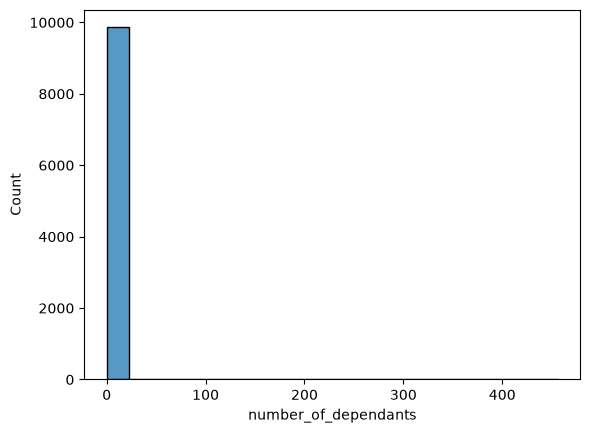

In [20]:
sns.histplot(df2.number_of_dependants, bins = 20)

In [21]:
dependents_threshold = df2.number_of_dependants.quantile(0.99)
dependents_threshold

np.float64(5.0)

In [22]:
df3 = df2[df2['number_of_dependants']<=dependents_threshold].copy()
df3.number_of_dependants.describe()

count    9858.000000
mean        1.919963
std         1.503027
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: number_of_dependants, dtype: float64

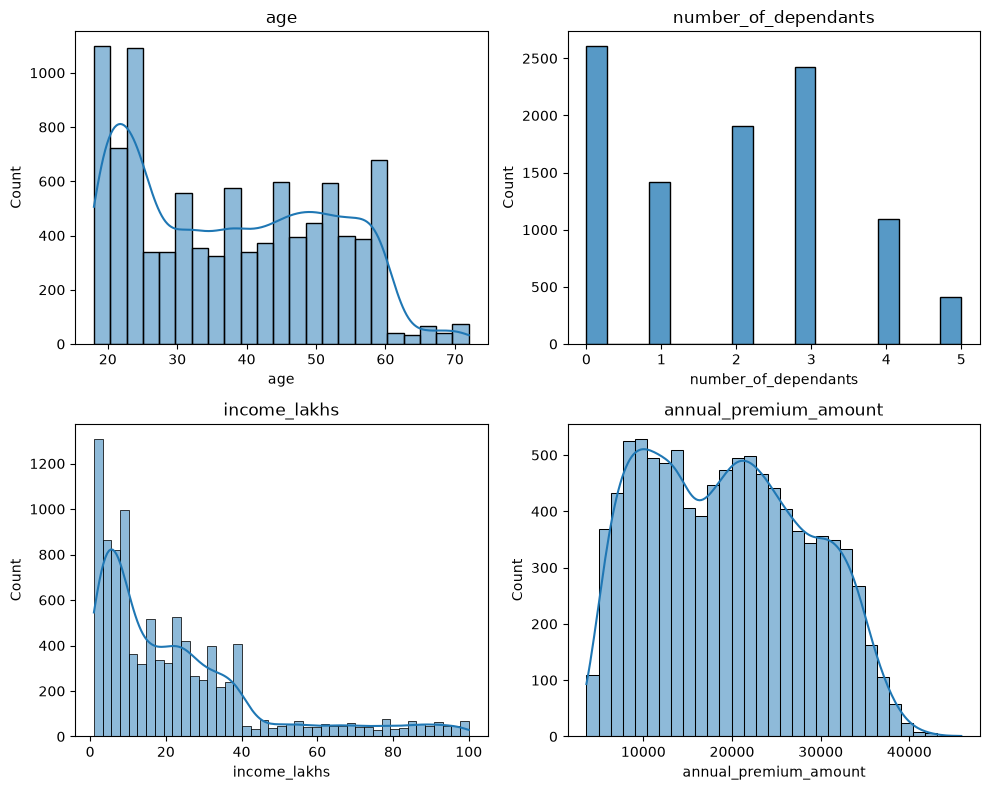

In [23]:
discrete_columns = ['number_of_dependants']   # columns that only take whole numbers

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

for i, column in enumerate(numeric_columns):
    ax = axs[i//2, i%2]
    use_kde = column not in discrete_columns   # True for continuous, False for discrete
    sns.histplot(df3[column], kde=use_kde, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

- age: right-skewed. Large cluster in the early twenties, fairly even spread from the mid twenties to about 60, then very few customers above 60.
- number_of_dependants: discrete (0 to 5). Zero is the most common value, followed by 3 and 2. KDE is switched off because a smooth curve is not meaningful for whole-number data.
- income_lakhs: heavily right-skewed. Most values are below 40 lakhs, with a long thin tail up to 100. Candidate for a log transformation and outlier checks.
 - annual_premium_amount: bimodal, with peaks around 10,000 and 22,000, suggesting two distinct customer groups (possibly different plan types).

#### BiVariate Analysis

In [24]:
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='str')

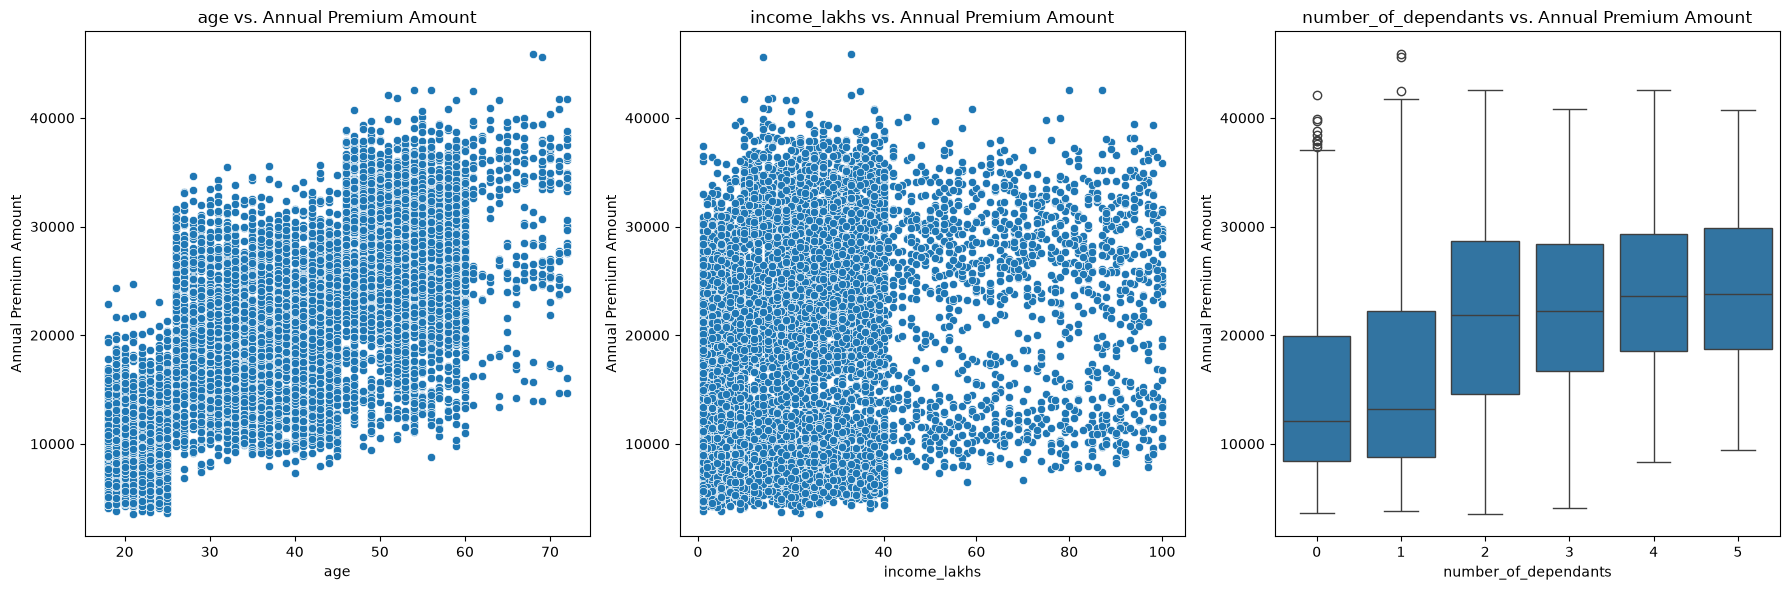

In [25]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# age (continuous): scatter plot
sns.scatterplot(x=df3['age'], y=df3['annual_premium_amount'], ax=axes[0])
axes[0].set_title('age vs. Annual Premium Amount')
axes[0].set_xlabel('age')
axes[0].set_ylabel('Annual Premium Amount')

# income_lakhs (continuous): scatter plot
sns.scatterplot(x=df3['income_lakhs'], y=df3['annual_premium_amount'], ax=axes[1])
axes[1].set_title('income_lakhs vs. Annual Premium Amount')
axes[1].set_xlabel('income_lakhs')
axes[1].set_ylabel('Annual Premium Amount')

# number_of_dependants (discrete): box plot, one box per dependant count
sns.boxplot(x=df3['number_of_dependants'], y=df3['annual_premium_amount'], ax=axes[2])
axes[2].set_title('number_of_dependants vs. Annual Premium Amount')
axes[2].set_xlabel('number_of_dependants')
axes[2].set_ylabel('Annual Premium Amount')

plt.tight_layout()
plt.show()

 Observations:
- age vs premium: clear positive relationship. Premiums rise with age in visible steps (roughly under 25, 25 to 45, and 45 plus), suggesting the premium is partly set by age bracket. Strongest numeric predictor.
- income_lakhs vs premium: no obvious trend. Premiums are spread across the full range at every income level. The dense block under 40 lakhs reflects where most customers sit, not a different pricing pattern. Weak predictor on its own.
- number_of_dependants vs premium: dependants is a whole number (0 to 5), so a scatter plot just stacks dots into vertical lines. A box plot is used instead to compare the typical premium for each dependant count. The boxes sit at similar levels, so the number of dependants has little effect on the premium.

### 2. Categorical Columns

In [26]:
df3.head(2)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108


In [27]:
categorical_cols = ['gender', 'region', 'marital_status', 'physical_activity', 'stress_level', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']
for col in categorical_cols:
    print(col, ":", df3[col].unique())

gender : <StringArray>
['Female', 'Male']
Length: 2, dtype: str
region : <StringArray>
['Southeast', 'Northeast', 'Southwest', 'Northwest']
Length: 4, dtype: str
marital_status : <StringArray>
['Unmarried', 'Married']
Length: 2, dtype: str
physical_activity : <StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str
stress_level : <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
bmi_category : <StringArray>
['Normal', 'Overweight', 'Obesity', 'Underweight']
Length: 4, dtype: str
smoking_status : <StringArray>
['No Smoking', 'Occasional', 'Regular']
Length: 3, dtype: str
employment_status : <StringArray>
['Self-Employed', 'Freelancer', 'Salaried']
Length: 3, dtype: str
income_level : <StringArray>
['25L - 40L', '10L - 25L', '<10L', '> 40L']
Length: 4, dtype: str
medical_history : <StringArray>
[                'High blood pressure',                          'No Disease',
                             'Thyroid', 'High blood pressure & Heart disease',
                  'Di

#### Univariate Analysis

In [28]:
pct_count =  (df3['gender'].value_counts(normalize=True)*100).round(2)
pct_count

gender
Female    59.87
Male      40.13
Name: proportion, dtype: float64

<Axes: xlabel='gender'>

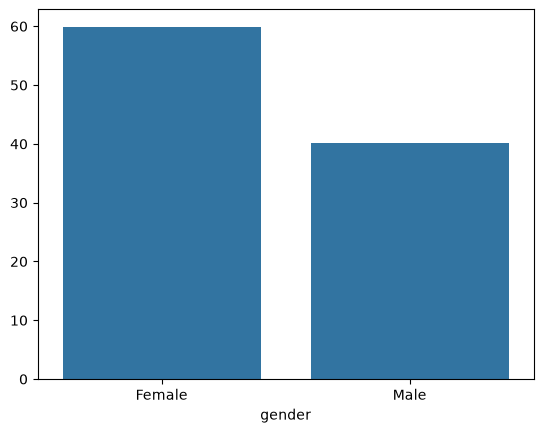

In [29]:
sns.barplot(x=pct_count.index, y=pct_count.values)

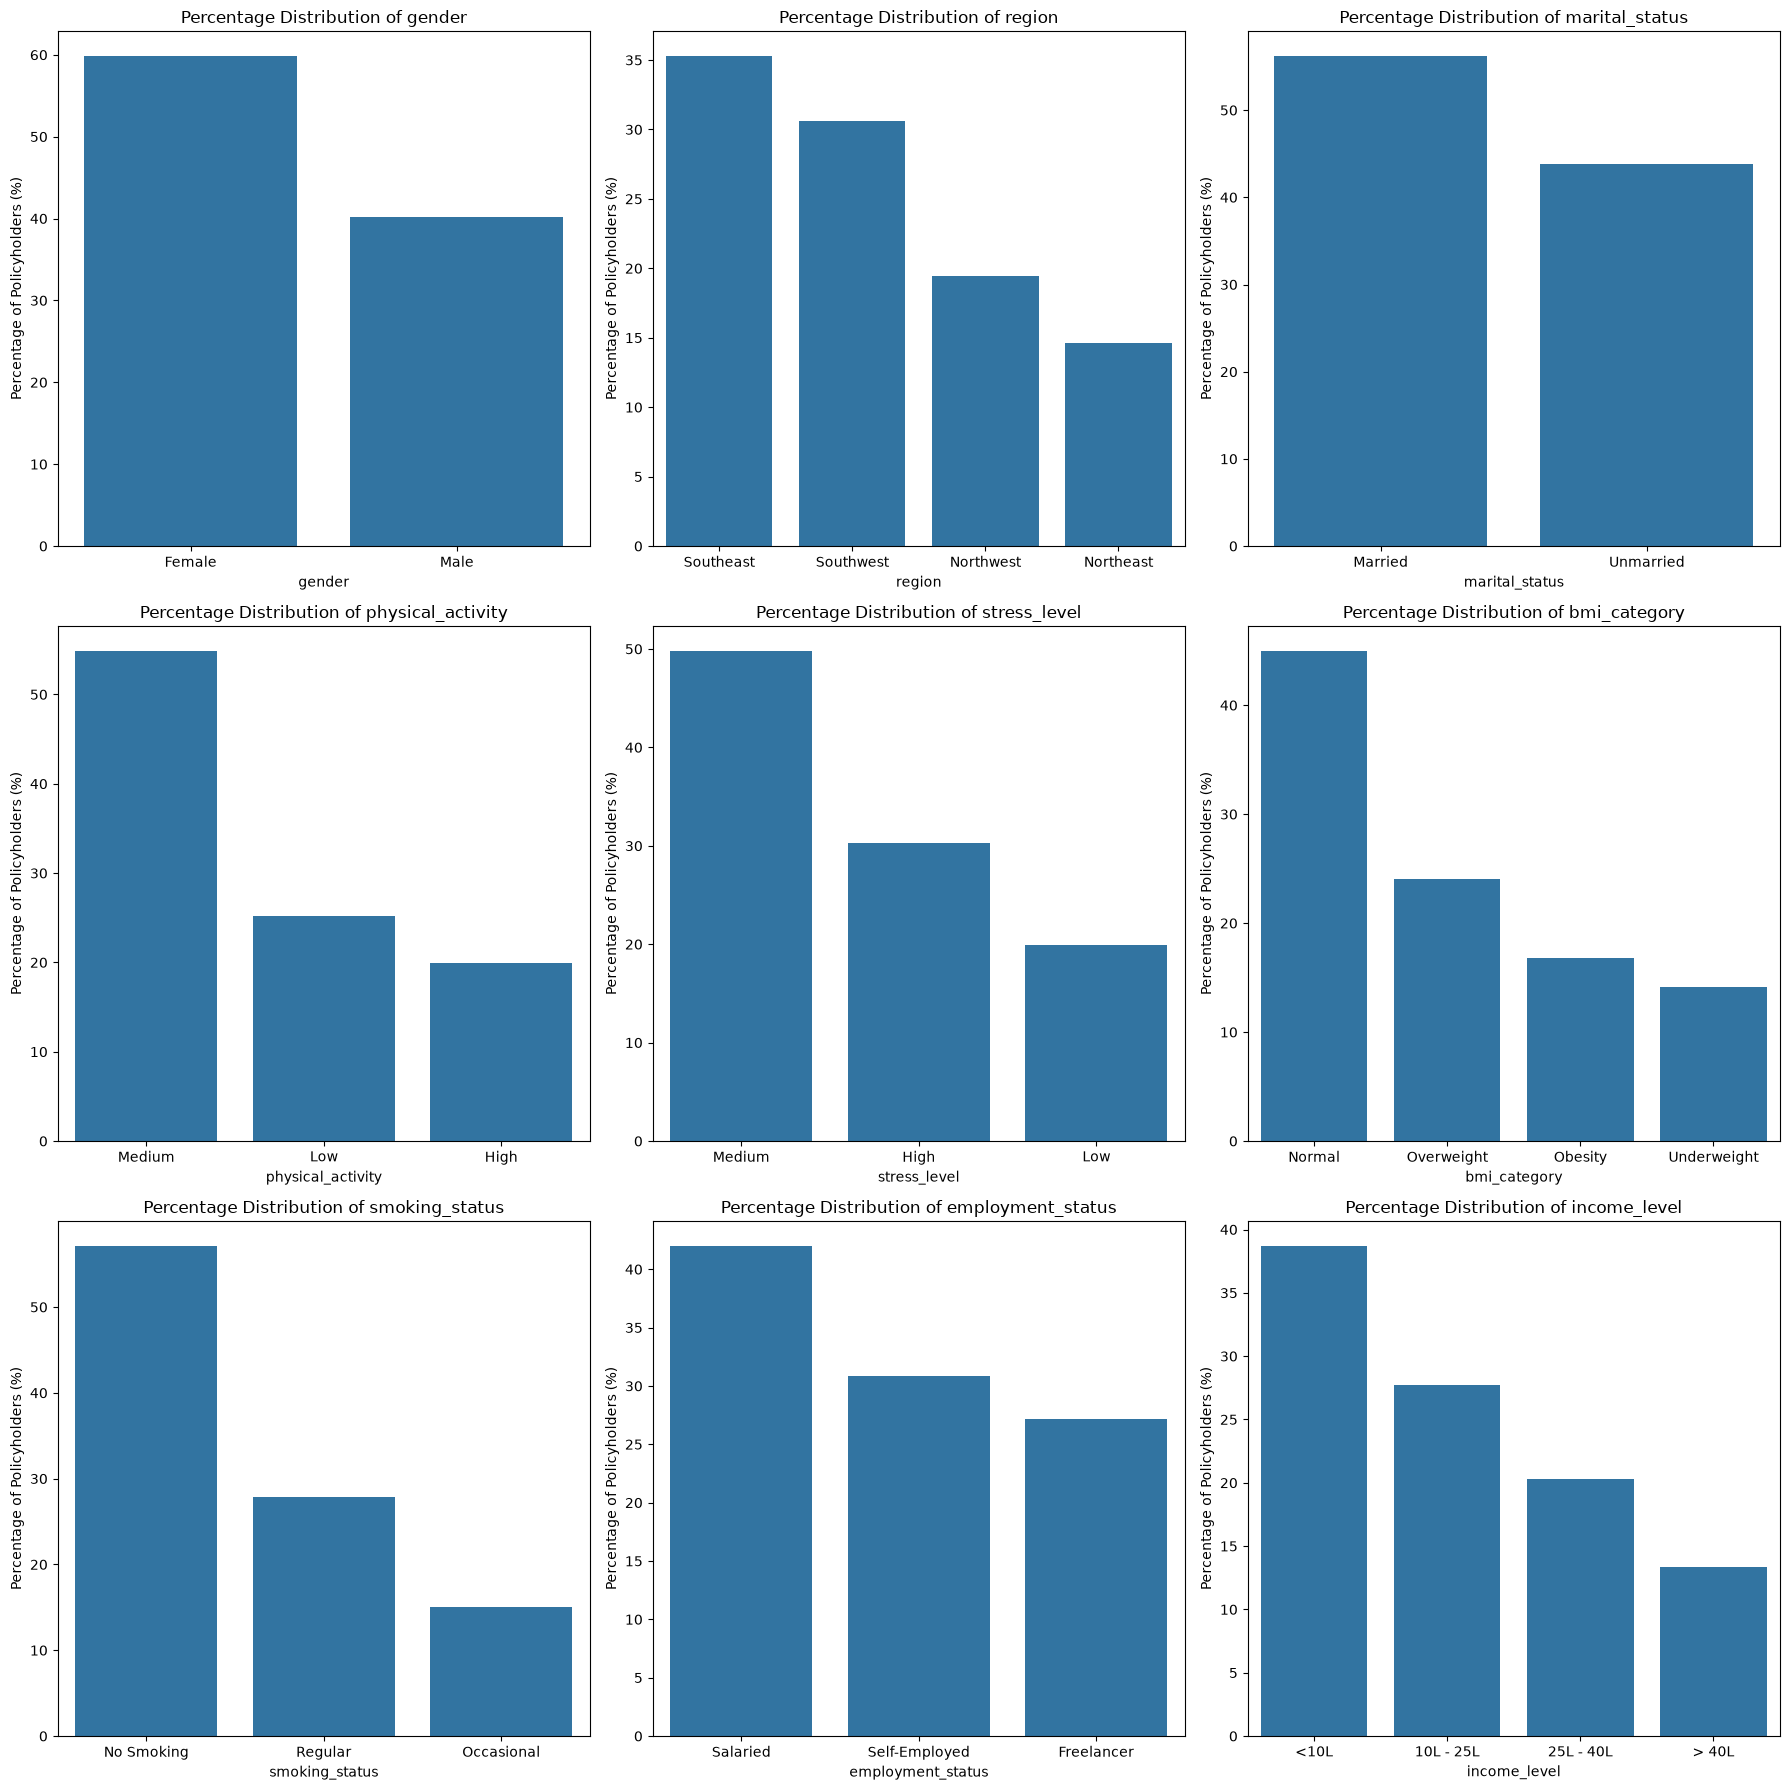

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df3[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

Observations:
- gender: Female about 60%, Male about 40%. Moderate imbalance.
- region: Southeast (35%) and Southwest (31%) dominate; Northwest (19%) and Northeast (15%) are smaller, so the model has less data on the north.
- marital_status: Married about 56%, Unmarried about 44%. Fairly balanced.
- physical_activity: Medium (55%), Low (25%), High (20%).
- stress_level: Medium (50%), High (30%), Low (20%).
- bmi_category: Normal (45%), Overweight (24%), Obesity (17%), Underweight (14%).
- smoking_status: No Smoking (57%), Regular (28%), Occasional (15%). Likely an important premium driver.
- employment_status: Salaried (42%), Self-Employed (31%), Freelancer (27%).
- income_level: <10L (39%), 10L-25L (28%), 25L-40L (21%), >40L (13%). Mirrors the right-skewed income_lakhs histogram.

Conclusions:
- No category is rare enough to need merging or dropping; the smallest share is around 13-15%.
- Several columns are dominated by a middle or default group (Medium activity, Medium stress, Normal BMI, No Smoking), which is typical of a real population.
- income_level and income_lakhs carry the same information; consider keeping only one for modelling.
- These charts describe the population only. Next step: box plots of annual_premium_amount by each category to see which ones drive the premium.

/var/folders/wk/qmj8v7591nxgj48vf3xl6n3m0000gn/T/ipykernel_67920/453596315.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df3.select_dtypes(include='object').columns.tolist()


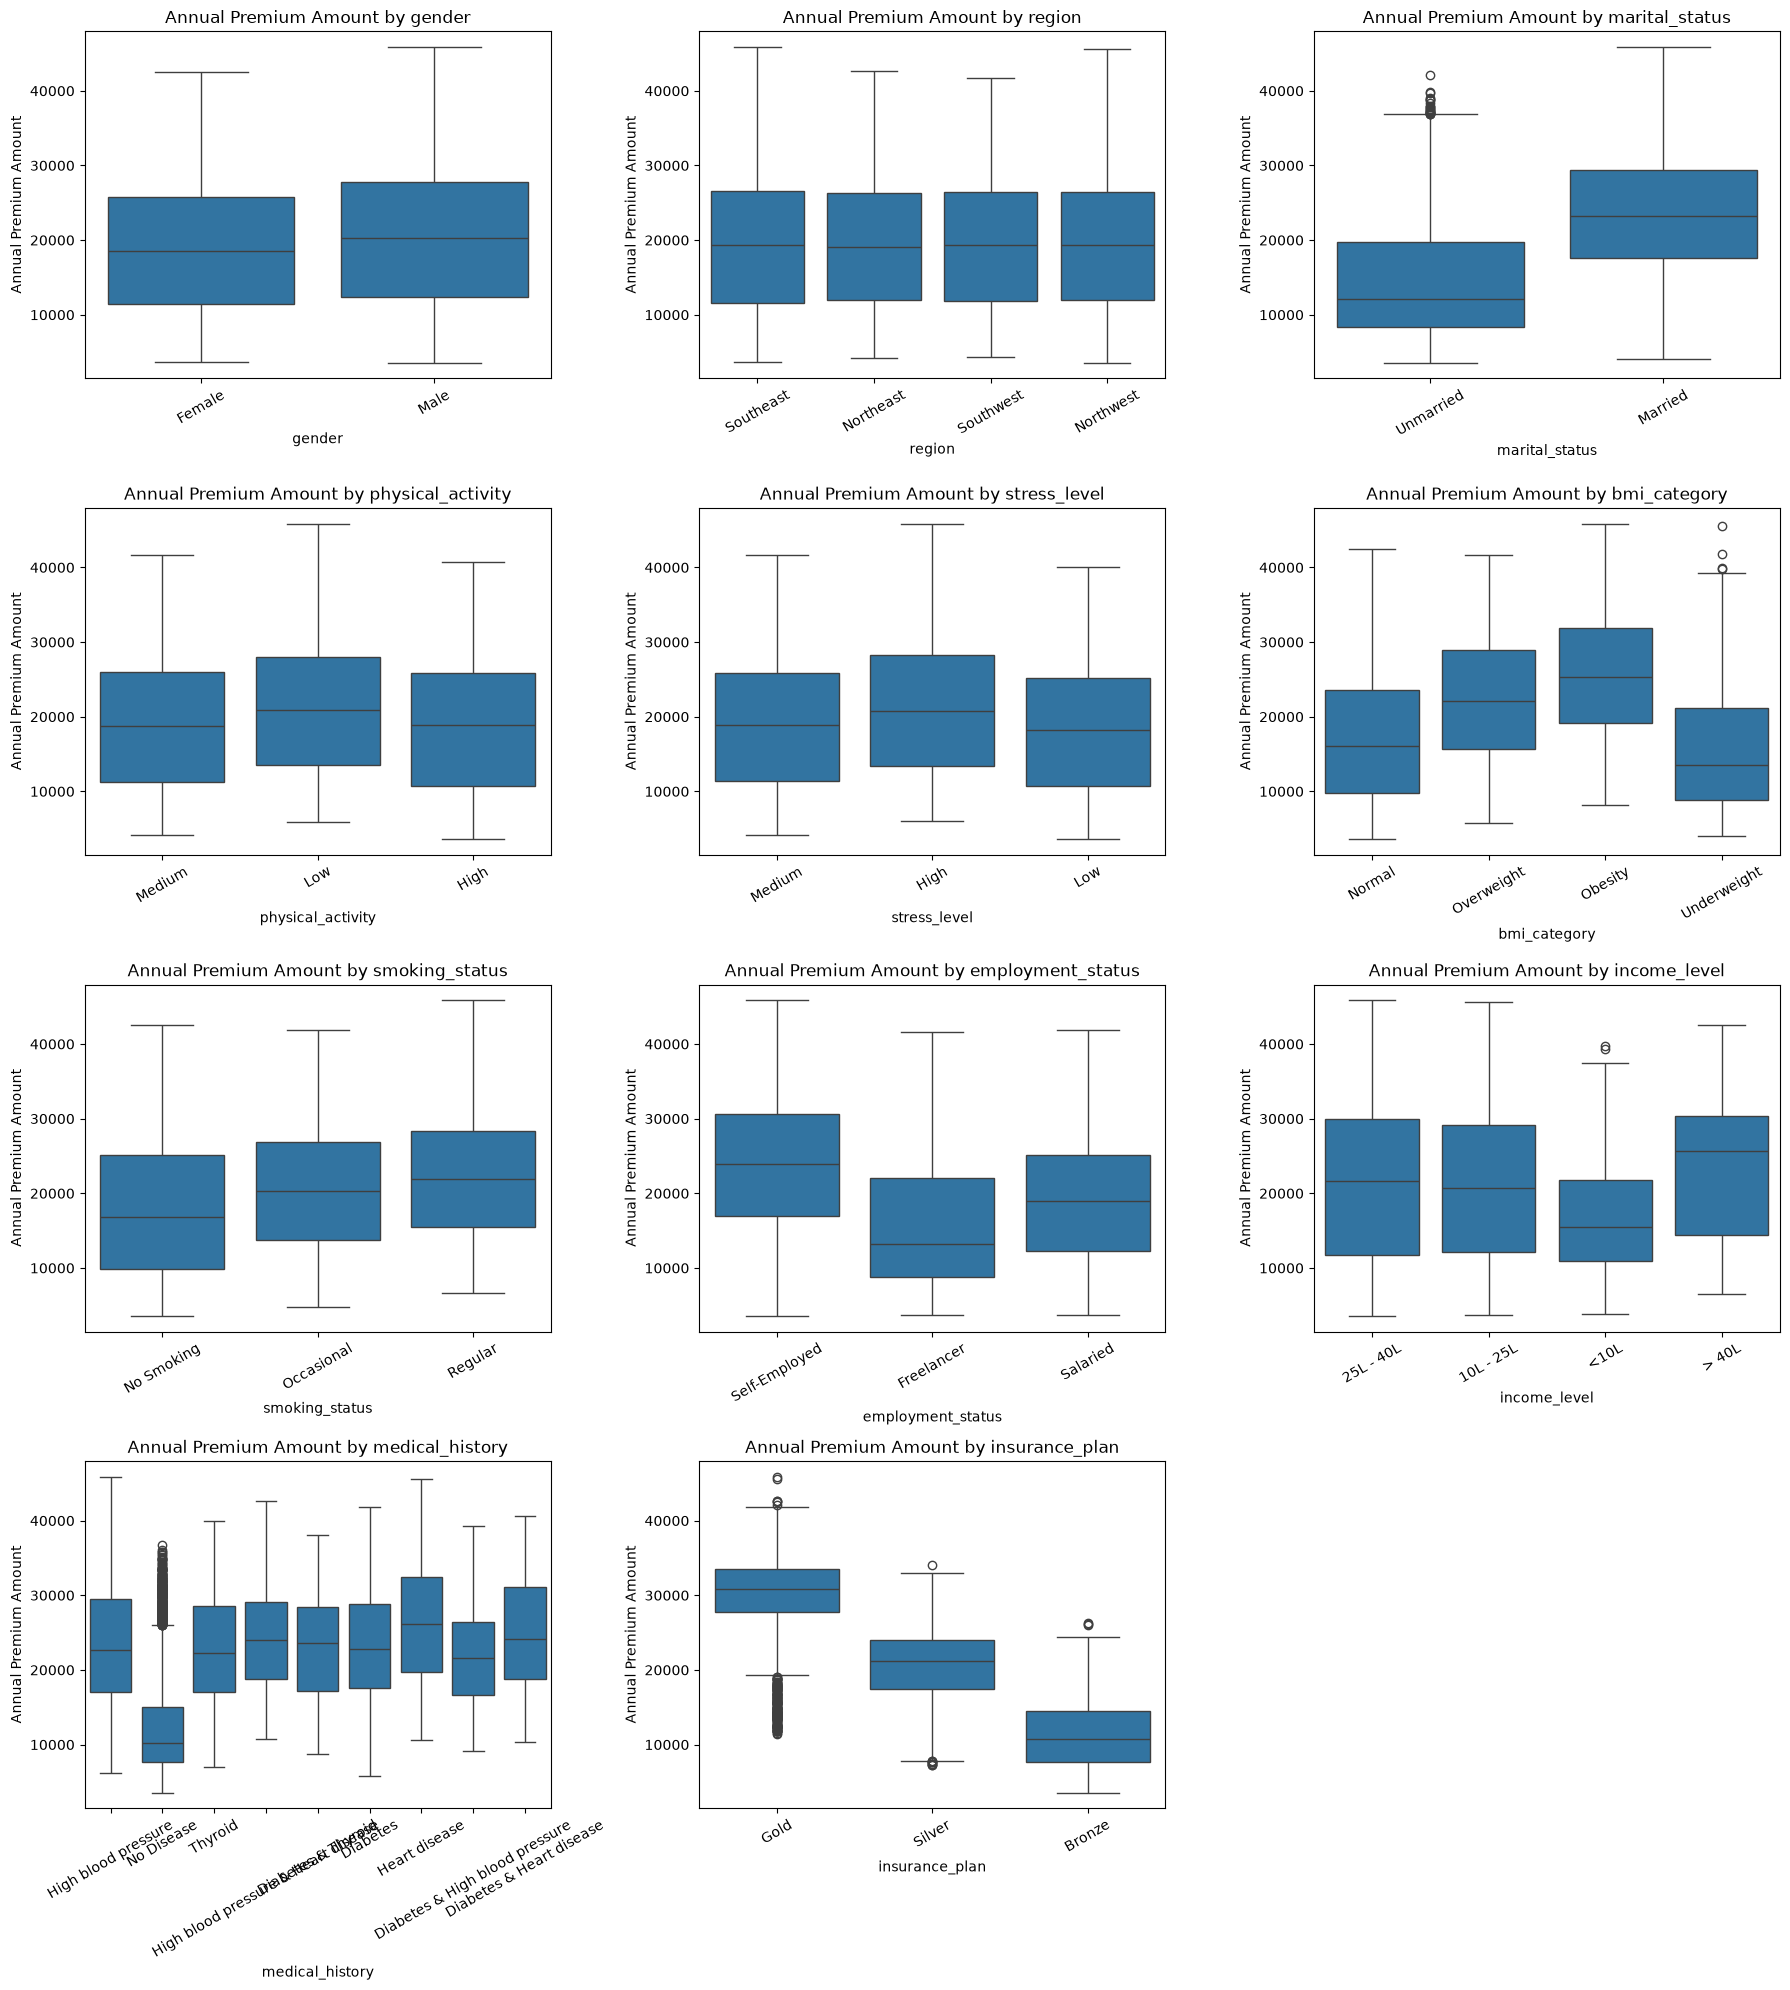

In [31]:
# Premium by category
#
# Purpose: for each categorical column, compare the spread of
# annual_premium_amount across its categories. If the boxes sit at clearly
# different heights, that column helps explain the premium.

# Pick out the text columns automatically. Add or remove names if needed.

import math
categorical_columns = df3.select_dtypes(include='object').columns.tolist()

ncols = 3
nrows = math.ceil(len(categorical_columns) / ncols)   # enough rows to fit them all

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axs = axs.flatten()   # turn the 2D grid into a simple list so we can index with i

for i, column in enumerate(categorical_columns):
    sns.boxplot(x=df3[column], y=df3['annual_premium_amount'], ax=axs[i])
    axs[i].set_title(f'Annual Premium Amount by {column}')
    axs[i].set_xlabel(column)
    axs[i].set_ylabel('Annual Premium Amount')
    axs[i].tick_params(axis='x', rotation=30)   # tilt long labels so they do not overlap

# Hide any empty cells left over at the end of the grid
for j in range(len(categorical_columns), len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()

Strong drivers (medians clearly separated):
- insurance_plan: Gold ~31k, Silver ~21k, Bronze ~12k. Explains the two peaks in the premium histogram. Expected to be the top feature.
- medical_history: No Disease ~11k; all conditions 22k-26k, combined conditions highest.
- marital_status: Unmarried ~12k vs Married ~23k. Likely partly an age effect.
- bmi_category: rises from Underweight (~14k) and Normal (~16k) to Overweight (~22k) and Obesity (~25k).

Moderate drivers (direction clear, boxes overlap):
- smoking_status: Regular ~22k, Occasional ~20k, No Smoking ~17k.
- employment_status: Self-Employed ~24k, Salaried ~19k, Freelancer ~13k.
- income_level: higher bands pay more, but overlap is large.

Weak or no effect (medians within a few thousand, boxes overlap fully):
- gender, region, physical_activity, stress_level.
    
Notes:
- Effects overlap (married, older, Gold plan and medical conditions tend to go together), so each plot mixes several causes. The model will separate them.
- Outlier dots are genuine customers whose premium is unusual for their group, not data errors.

## Feature Engineering

In [32]:
df3.head(2)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108


### Calculate Risk Score

In [33]:
# Define the risk scores for each condition
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure": 6,
    "thyroid": 5,
    "no disease": 0,
    "none": 0
}

# Split "Diabetes & Heart disease" into two columns and lower-case them
df3[['disease1', 'disease2']] = (
    df3['medical_history']
    .str.split(" & ", expand=True)
    .apply(lambda x: x.str.lower())
)

# Rows with only one condition have NaN in disease2; replace with 'none'
df3['disease1'] = df3['disease1'].fillna('none')
df3['disease2'] = df3['disease2'].fillna('none')

# Add up the risk score for each condition
df3['total_risk_score'] = 0
for disease in ['disease1', 'disease2']:
    df3['total_risk_score'] += df3[disease].map(risk_scores)

# Normalise the risk score to a range of 0 to 1
max_score = df3['total_risk_score'].max()
min_score = df3['total_risk_score'].min()
df3['normalized_risk_score'] = (df3['total_risk_score'] - min_score) / (max_score - min_score)

df3.head(2)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,high blood pressure,none,6,0.428571
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,no disease,none,0,0.000000


### Calculate Life Style Risk Score

In [34]:
def calculate_life_style_risk(row):
    physical_activity_risk_score = {
        "High": 0,
        "Medium": 1,
        "Low": 4
    }
    stress_risk_score = {
        "High": 4,
        "Medium": 1,
        "Low": 0
    }
    life_style_risk = physical_activity_risk_score[row['physical_activity']] + stress_risk_score[row['stress_level']]
    return life_style_risk

df3['lifestyle_risk_score'] = df3.apply(calculate_life_style_risk, axis=1)

<Axes: xlabel='lifestyle_risk_score', ylabel='Count'>

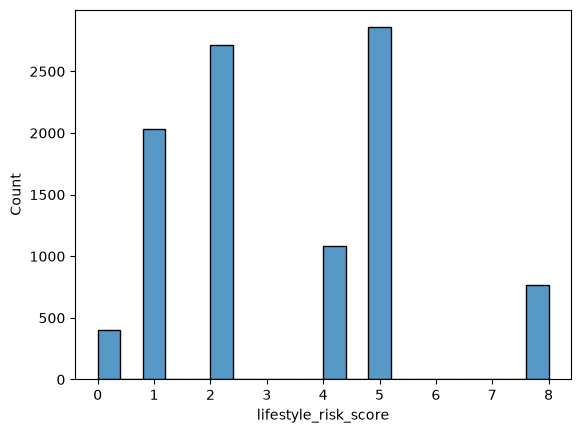

In [35]:
sns.histplot(df3.lifestyle_risk_score, bins=20)

### Encode Text Columns

In [36]:
df3.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score,lifestyle_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,high blood pressure,none,6,0.428571,2
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,no disease,none,0,0.000000,8
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459,no disease,none,0,0.000000,5
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685,thyroid,none,5,0.357143,1
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,high blood pressure,heart disease,14,1.000000,5


In [37]:
df3['insurance_plan'] = df3['insurance_plan'].map({'Bronze':1, 'Silver':2, 'Gold':3})

df3.head(2)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score,lifestyle_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,3,27944,high blood pressure,none,6,0.428571,2
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,2,21108,no disease,none,0,0.000000,8


In [38]:
df3.income_level.unique()

<StringArray>
['25L - 40L', '10L - 25L', '<10L', '> 40L']
Length: 4, dtype: str

In [39]:
df3['income_level'] = df3['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})
df3.head(3)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score,lifestyle_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,3,37,High blood pressure,3,27944,high blood pressure,none,6,0.428571,2
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,2,10,No Disease,2,21108,no disease,none,0,0.000000,8
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,1,9,No Disease,1,8459,no disease,none,0,0.000000,5


In [40]:
df3.income_level.unique()

array([3, 2, 1, 4])

In [41]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df4 = pd.get_dummies(df3, columns=nominal_cols, drop_first=True, dtype=int)
df4.head(3)

,age,physical_activity,stress_level,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,56,Medium,Medium,2,3,37,High blood pressure,3,27944,high blood pressure,...,1,0,1,0,0,0,0,0,0,1
1,38,Low,High,5,2,10,No Disease,2,21108,no disease,...,0,0,0,0,1,0,1,0,0,0
2,18,Medium,High,0,1,9,No Disease,1,8459,no disease,...,0,1,1,0,0,0,0,0,0,0


In [42]:
df4.info()

<class 'pandas.DataFrame'>
Index: 9858 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              9858 non-null   int64  
 1   physical_activity                9858 non-null   str    
 2   stress_level                     9858 non-null   str    
 3   number_of_dependants             9858 non-null   int64  
 4   income_level                     9858 non-null   int64  
 5   income_lakhs                     9858 non-null   int64  
 6   medical_history                  9858 non-null   str    
 7   insurance_plan                   9858 non-null   int64  
 8   annual_premium_amount            9858 non-null   int64  
 9   disease1                         9858 non-null   str    
 10  disease2                         9858 non-null   str    
 11  total_risk_score                 9858 non-null   int64  
 12  normalized_risk_score            985

### Feature Selection

In [43]:
df5 = df4.drop(['medical_history', 'disease1', 'disease2', 'total_risk_score','physical_activity', 'stress_level'], axis=1)
df5.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,lifestyle_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,56,2,3,37,3,27944,0.428571,2,0,0,1,0,1,0,0,0,0,0,0,1
1,38,5,2,10,2,21108,0.000000,8,0,0,0,0,0,0,1,0,1,0,0,0
2,18,0,1,9,1,8459,0.000000,5,0,0,0,1,1,0,0,0,0,0,0,0


### Calculate VIF for Multicolinearity

In [44]:
df5.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'lifestyle_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='str')

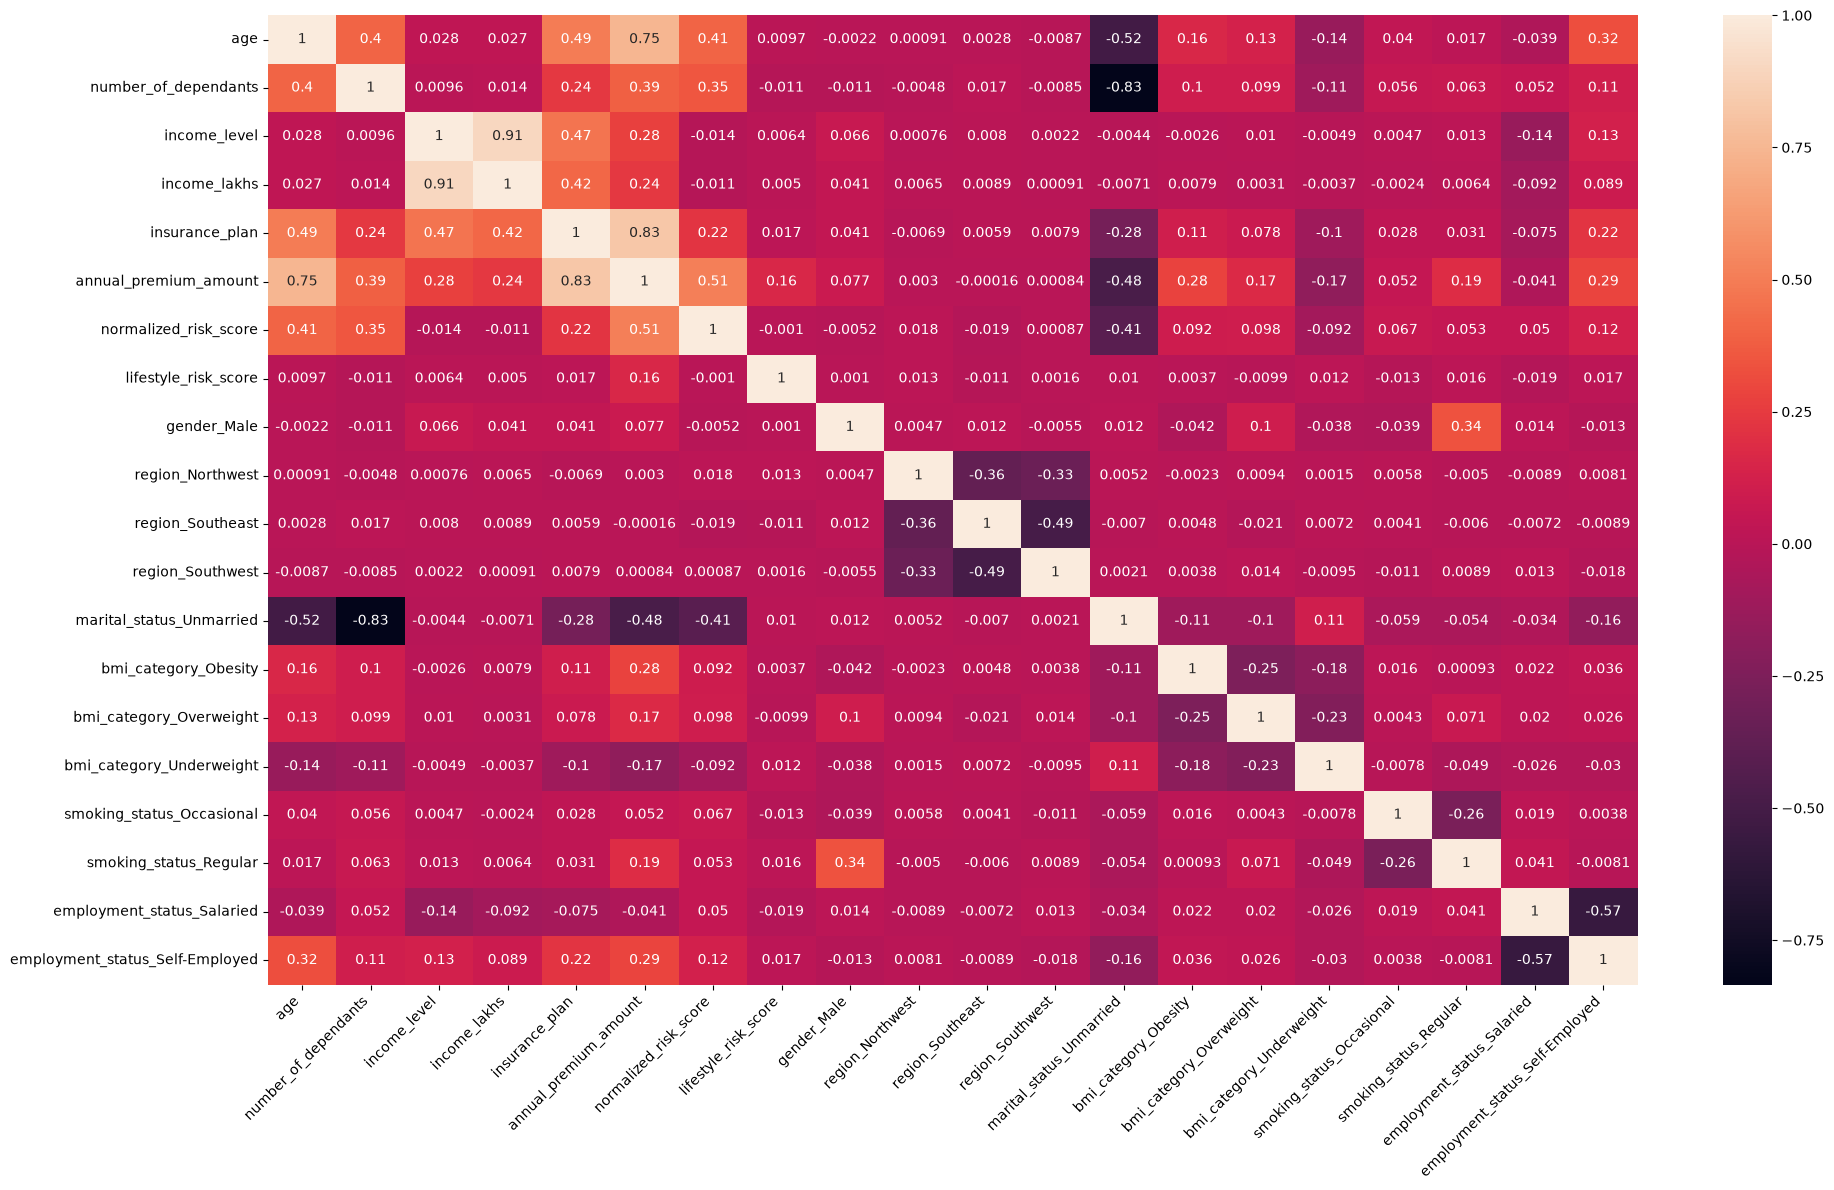

In [45]:
cm = df5.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
X = df5.drop('annual_premium_amount', axis='columns')
y = df5['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age', 'number_of_dependants','income_level', 'income_lakhs', 'insurance_plan', 'lifestyle_risk_score']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,lifestyle_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000
mean,0.366014,0.383993,0.360756,0.219027,0.446135,0.326537,0.408349,0.401298,0.194664,0.353013,0.306452,0.437716,0.167985,0.240414,0.141712,0.150030,0.278657,0.420065,0.308176
std,0.258820,0.300605,0.352198,0.226801,0.395765,0.279083,0.268302,0.490186,0.395962,0.477931,0.461043,0.496131,0.373872,0.427356,0.348773,0.357119,0.448361,0.493594,0.461763
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.111111,0.000000,0.000000,0.050505,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.351852,0.400000,0.333333,0.151515,0.500000,0.428571,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.592593,0.600000,0.666667,0.303030,1.000000,0.428571,0.625000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [48]:
calculate_vif(X)

,Column,VIF
0,age,1.993284
1,number_of_dependants,3.326672
2,income_level,6.153287
3,income_lakhs,5.664192
4,insurance_plan,1.826983
5,normalized_risk_score,1.298650
6,lifestyle_risk_score,1.001814
7,gender_Male,1.153454
8,region_Northwest,1.883189
9,region_Southeast,2.218834


In [49]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,1.967995
1,number_of_dependants,3.326621
2,income_lakhs,1.288539
3,insurance_plan,1.706543
4,normalized_risk_score,1.298414
5,lifestyle_risk_score,1.001812
6,gender_Male,1.149322
7,region_Northwest,1.882802
8,region_Southeast,2.218634
9,region_Southwest,2.154591


In [50]:
# we will drop income_lakhs due to high VIF value
X_reduced = X.drop('income_level', axis="columns")

X = X_reduced
X.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,lifestyle_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.703704,0.4,0.363636,1.0,0.428571,0.250,0,0,1,0,1,0,0,0,0,0,0,1
1,0.370370,1.0,0.090909,0.5,0.000000,1.000,0,0,0,0,0,0,1,0,1,0,0,0
2,0.000000,0.0,0.080808,0.0,0.000000,0.625,0,0,0,1,1,0,0,0,0,0,0,0
3,0.685185,0.6,0.080808,0.5,0.357143,0.125,1,0,0,0,0,0,1,0,1,0,1,0
4,0.074074,0.4,0.121212,0.0,1.000000,0.625,1,0,1,0,1,0,0,0,0,1,0,1


## Model Training

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (6900, 18)
x test:  (2958, 18)
y train:  (6900,)
y test:  (2958,)


### Linear Regression Model

In [52]:
#Training the model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test,y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.9583441168970603, 0.957877163116046)

In [53]:
# Predicting and assessing model's accuracy
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  3271494.4534015623 RMSE:  1808.7273021109518


In [54]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([10816.978546,  -636.570995,  -766.012668, 13259.727101,
        6487.236252,  4722.854268,    84.78725 ,    76.516451,
         113.662324,     0.625549,  -769.22107 ,  4121.871374,
        2068.552203,   364.012454,  1190.632535,  3087.600539,
          44.86986 ,   364.430996])

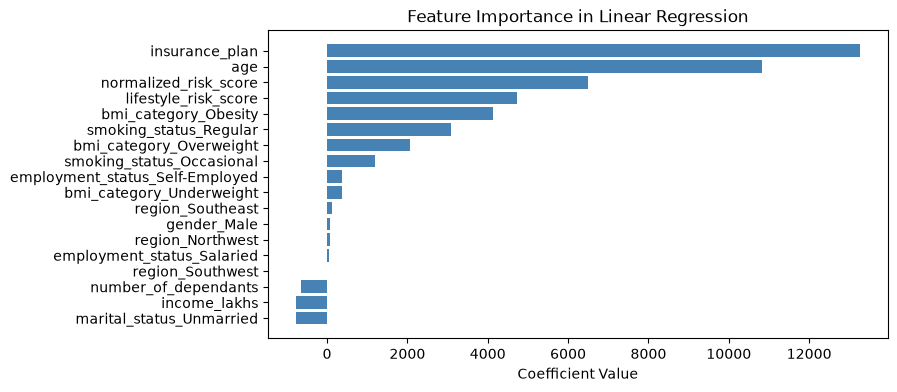

In [55]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

### XGBoost

In [56]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth =3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9902917146682739

In [57]:
y_pred = model_xgb.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  753999.8125 RMSE:  868.3316258780397


In [58]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.9923675457636515)

In [59]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [60]:
best_model = random_search.best_estimator_

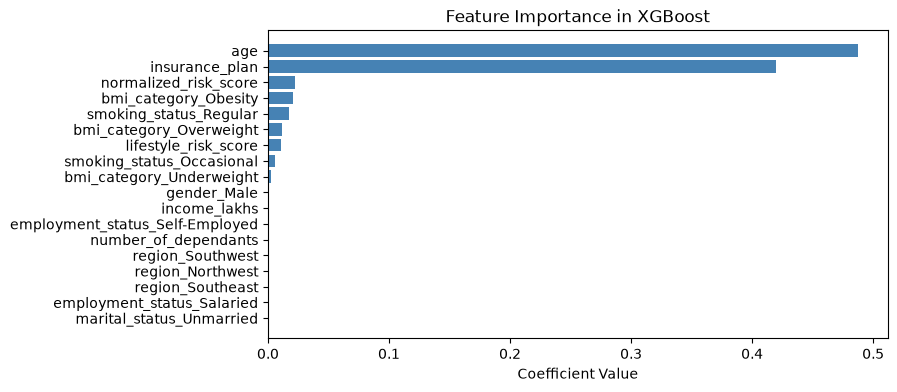

In [61]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

In [62]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals/y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals, 
    'diff_pct': residuals_pct
})

results_df.head()

,actual,predicted,diff,diff_pct
8496,30733,30284.162109,-448.837891,-1.460443
507,32997,32523.818359,-473.181641,-1.434014
5147,15251,16731.519531,1480.519531,9.707688
887,6936,7782.151367,846.151367,12.199414
8848,10909,11759.937500,850.937500,7.800325


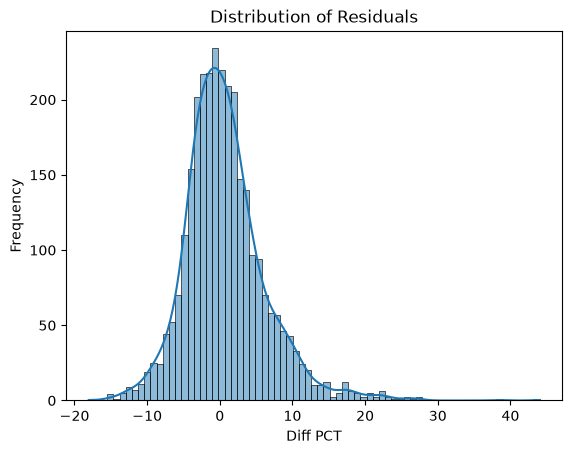

In [63]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

### Error Analysis

In [64]:
extreme_error_threshold = 10  
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
887,6936,7782.151367,846.151367,12.199414
8963,14296,15982.426758,1686.426758,11.796494
4879,6422,7070.936035,648.936035,10.104890
1918,7431,8502.357422,1071.357422,14.417406
7772,7225,6290.117676,-934.882324,-12.939548


In [65]:
extreme_results_df.shape

(213, 4)

In [66]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

7.200811359026369

About 93% of the time, my model predicts the insurance premium within 10% of the actual value. About 7% of the time, it's off by more than that.

In [67]:
# Join feature columns back onto extreme_results_df
extreme_with_features = X_test.loc[extreme_results_df.index].copy()
extreme_with_features['actual'] = extreme_results_df['actual']
extreme_with_features['predicted'] = extreme_results_df['predicted']
extreme_with_features['diff_pct'] = extreme_results_df['diff_pct']

extreme_with_features.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,lifestyle_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,...,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,actual,predicted,diff_pct
887,0.111111,0.0,0.161616,0.0,0.000000,0.625,0,0,0,1,...,0,0,0,0,0,0,0,6936,7782.151367,12.199414
8963,0.055556,0.6,0.666667,0.5,0.357143,0.625,0,0,0,1,...,0,1,0,0,0,0,0,14296,15982.426758,11.796494
4879,0.037037,0.0,0.313131,0.0,0.000000,0.500,0,0,0,1,...,0,0,0,0,0,0,0,6422,7070.936035,10.104890
1918,0.129630,0.0,0.323232,0.5,0.000000,0.000,0,0,0,1,...,0,0,0,0,0,1,0,7431,8502.357422,14.417406
7772,0.129630,0.2,0.000000,0.0,0.000000,0.250,1,0,0,0,...,0,0,1,0,0,0,0,7225,6290.117676,-12.939548


In [68]:
print("=== Feature averages ===")
comparison = pd.DataFrame({
    'all_test': X_test.mean(),
    'extreme_errors': X_test.loc[extreme_results_df.index].mean(),
})
comparison['difference'] = comparison['extreme_errors'] - comparison['all_test']
print(comparison.sort_values('difference', key=abs, ascending=False))

=== Feature averages ===
                                 all_test  extreme_errors  difference
insurance_plan                   0.438134        0.082160   -0.355974
marital_status_Unmarried         0.421569        0.760563    0.338995
age                              0.367190        0.161015   -0.206175
normalized_risk_score            0.327659        0.130449   -0.197209
bmi_category_Overweight          0.241717        0.051643   -0.190074
number_of_dependants             0.390872        0.202817   -0.188055
smoking_status_Regular           0.277214        0.112676   -0.164538
employment_status_Self-Employed  0.308654        0.154930   -0.153725
lifestyle_risk_score             0.411596        0.282864   -0.128732
bmi_category_Obesity             0.165652        0.042254   -0.123399
bmi_category_Underweight         0.141650        0.201878    0.060228
income_lakhs                     0.217086        0.163560   -0.053526
smoking_status_Occasional        0.153482        0.112676   -0.04

Two candidate explanations, and both are worth investigating:

Explanation A — Missing structure. There's something about "basic plan + unmarried + low-risk profile" that drives premiums in a way features don't capture. Maybe these customers have varied claim patterns that come down to factors not in the dataset (occupation risk, hobbies, family history). The features I have simply aren't enough to distinguish who among this group will cost more vs less.

Explanation B — Data leakage or feature dominance. The insurance_plan feature might be doing too much work in the model. If premium is heavily driven by plan tier, the model may have learned "expensive plan → high premium" as its dominant rule, and it fails to differentiate among basic-plan customers where the plan doesn't help predict.

In [69]:
over = extreme_results_df[extreme_results_df['diff_pct'] > 0]
under = extreme_results_df[extreme_results_df['diff_pct'] < 0]

print(f"Over-predicted: {len(over)}")
print(f"Under-predicted: {len(under)}")

# Compare feature averages between over and under
over_features = X_test.loc[over.index].mean()
under_features = X_test.loc[under.index].mean()
print("\nOver-predictions - Under-predictions:")
print((over_features - under_features).sort_values(key=abs, ascending=False))

Over-predicted: 168
Under-predicted: 45

Over-predictions - Under-predictions:
bmi_category_Underweight          -0.279365
smoking_status_Occasional         -0.223413
marital_status_Unmarried          -0.162698
gender_Male                       -0.158333
smoking_status_Regular            -0.138889
region_Southeast                  -0.093254
region_Southwest                   0.090476
age                                0.088316
number_of_dependants               0.065556
normalized_risk_score              0.064768
insurance_plan                     0.061905
bmi_category_Obesity              -0.059127
employment_status_Self-Employed    0.055556
region_Northwest                   0.049603
lifestyle_risk_score               0.045188
income_lakhs                       0.044300
employment_status_Salaried         0.028571
bmi_category_Overweight           -0.019048
dtype: float64


#### Error Analysis Findings
1. Errors are 4x more likely to be over-predictions than under-predictions (168 vs 45)
2. Model heavily anchored on `age` (48% importance) and `insurance_plan` (43%)
3. Errors concentrated in unmarried customers on basic plans with lower-than-average risk profiles
4. Suggests the model may need additional features (claim history, occupation) to differentiate basic-plan customers

#### Recommendations for Future Work
- Test model performance without dominant features to gauge real signal in others
- Consider separate models for premium vs basic plan customers
- Acquire additional customer risk features if possible